In [19]:
from typing import TypedDict, Literal

from langgraph.graph import StateGraph, START, END

In [20]:
class AgentState(TypedDict):
    learner_name: str
    email: str

    category: Literal[
        "technical",
        "billing",
        "course_content",
        "general"
    ]

    message: str
    days_until_deadline: int
    is_paid_student: bool

    priority_score: int

    priority: Literal[
        "low",
        "normal",
        "urgent"
    ]

    route: Literal[
        "urgent",
        "technical",
        "billing",
        "learning_support",
        "general"
    ]

    assigned_team: str
    status: str
    response: str
    audit_log: list[str]

In [21]:
def intake_node(state: AgentState) -> dict:

    audit = state["audit_log"] + [
        f"Request received for {state['learner_name']}."
    ]

    return {
        "status": "received",
        "audit_log": audit
    }

In [22]:
def calculate_priority_node(state: AgentState) -> dict:

    score = 0

    message = state["message"].lower()

    emergency_keywords = [
        "blocked",
        "cannot submit",
        "charged twice",
        "deadline"
    ]

    # Rule 1: urgent deadline
    if state["days_until_deadline"] <= 1:
        score += 50

    # Rule 2: technical issues are higher priority
    if state["category"] == "technical":
        score += 20

    # Rule 3: paid students receive slight boost
    if state["is_paid_student"]:
        score += 10

    # Rule 4: emergency keywords
    if any(keyword in message for keyword in emergency_keywords):
        score += 30

    # Determine priority
    if score >= 70:
        priority = "urgent"
    elif score >= 40:
        priority = "normal"
    else:
        priority = "low"

    audit = state["audit_log"] + [
        f"Priority calculated: {priority} ({score})."
    ]

    return {
        "priority_score": score,
        "priority": priority,
        "audit_log": audit
    }

In [23]:
def route_request(
    state: AgentState,
) -> Literal[
    "urgent",
    "technical",
    "billing",
    "learning_support",
    "general"
]:

    # Urgent overrides all categories
    if state["priority"] == "urgent":
        return "urgent"

    if state["category"] == "technical":
        return "technical"

    if state["category"] == "billing":
        return "billing"

    if state["category"] == "course_content":
        return "learning_support"

    return "general"

In [24]:
def route_request_node(state: AgentState) -> dict:
    return {}

In [25]:
def urgent_node(state: AgentState) -> dict:

    audit = state["audit_log"] + [
        "Urgent escalation assigned to on_call_instructor."
    ]

    return {
        "route": "urgent",
        "assigned_team": "on_call_instructor",
        "status": "escalated",
        "response": (
            f"{state['learner_name']}, your urgent request "
            f"has been escalated immediately."
        ),
        "audit_log": audit
    }

In [26]:
def technical_node(state: AgentState) -> dict:

    audit = state["audit_log"] + [
        "Technical support team assigned."
    ]

    return {
        "route": "technical",
        "assigned_team": "technical_support",
        "status": "triaged",
        "response": (
            f"{state['learner_name']}, your technical issue "
            f"has been assigned to technical support."
        ),
        "audit_log": audit
    }

In [27]:
def billing_node(state: AgentState) -> dict:

    audit = state["audit_log"] + [
        "Billing support team assigned."
    ]

    return {
        "route": "billing",
        "assigned_team": "billing_support",
        "status": "triaged",
        "response": (
            f"{state['learner_name']}, your billing request "
            f"has been assigned to billing support."
        ),
        "audit_log": audit
    }

In [28]:
def learning_support_node(state: AgentState) -> dict:

    audit = state["audit_log"] + [
        "Learning support team assigned."
    ]

    return {
        "route": "learning_support",
        "assigned_team": "learning_support_team",
        "status": "triaged",
        "response": (
            f"{state['learner_name']}, your course-content "
            f"question has been routed to learning support."
        ),
        "audit_log": audit
    }

In [29]:
def general_node(state: AgentState) -> dict:

    audit = state["audit_log"] + [
        "General support queue assigned."
    ]

    return {
        "route": "general",
        "assigned_team": "general_support",
        "status": "triaged",
        "response": (
            f"{state['learner_name']}, your request "
            f"has been received by general support."
        ),
        "audit_log": audit
    }

In [30]:
def summary_node(state: AgentState) -> dict:

    final_response = (
        f"{state['response']} "
        f"Priority: {state['priority']}. "
        f"Assigned Team: {state['assigned_team']}."
    )

    audit = state["audit_log"] + [
        "Triage summary completed."
    ]

    return {
        "response": final_response,
        "audit_log": audit
    }

In [31]:
graph = StateGraph(AgentState)

In [32]:
graph.add_node("intake_node", intake_node)
graph.add_node(
    "route_request_node",
    route_request_node
)
graph.add_node(
    "calculate_priority_node",
    calculate_priority_node
)

graph.add_node("urgent_node", urgent_node)
graph.add_node("technical_node", technical_node)
graph.add_node("billing_node", billing_node)
graph.add_node(
    "learning_support_node",
    learning_support_node
)
graph.add_node("general_node", general_node)

graph.add_node("summary_node", summary_node)

In [33]:
graph.add_edge(START, "intake_node")
graph.add_edge(
    "intake_node",
    "calculate_priority_node"
)
graph.add_edge(
    "calculate_priority_node",
    "route_request_node"
)
graph.add_conditional_edges(
    "route_request_node",
    route_request,
    {
        "urgent": "urgent_node",
        "technical": "technical_node",
        "billing": "billing_node",
        "learning_support": "learning_support_node",
        "general": "general_node"
    }
)
graph.add_edge("urgent_node", "summary_node")
graph.add_edge("technical_node", "summary_node")
graph.add_edge("billing_node", "summary_node")
graph.add_edge(
    "learning_support_node",
    "summary_node"
)
graph.add_edge("general_node", "summary_node")
graph.add_edge("summary_node", END)

In [34]:
workflow = graph.compile()

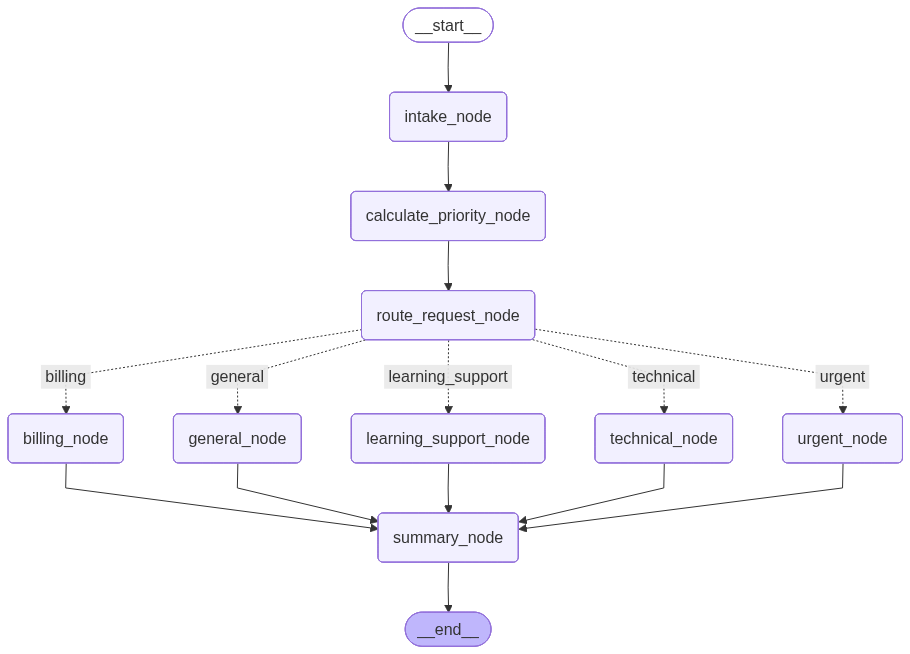

In [35]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [36]:
urgent_request = {
    "learner_name": "Ada",
    "email": "ada@example.com",
    "category": "technical",
    "message": "My project is blocked and deadline is tonight.",
    "days_until_deadline": 0,
    "is_paid_student": True,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "new",
    "response": "",
    "audit_log": []
}

In [37]:
result = workflow.invoke(urgent_request)

In [38]:
print(result)

{'learner_name': 'Ada', 'email': 'ada@example.com', 'category': 'technical', 'message': 'My project is blocked and deadline is tonight.', 'days_until_deadline': 0, 'is_paid_student': True, 'priority_score': 110, 'priority': 'urgent', 'route': 'urgent', 'assigned_team': 'on_call_instructor', 'status': 'escalated', 'response': 'Ada, your urgent request has been escalated immediately. Priority: urgent. Assigned Team: on_call_instructor.', 'audit_log': ['Request received for Ada.', 'Priority calculated: urgent (110).', 'Urgent escalation assigned to on_call_instructor.', 'Triage summary completed.']}


In [48]:
print("\nURGENT TEST")
print("Route:", result["route"])
print("Priority:", result["priority"])
print("Assigned Team:", result["assigned_team"])
print("Status:", result["status"])
print("Response:", result["response"])

print("\nAUDIT LOG")
for item in result["audit_log"]:
    print("-", item)


URGENT TEST
Route: urgent
Priority: urgent
Assigned Team: on_call_instructor
Status: escalated
Response: Ada, your urgent request has been escalated immediately. Priority: urgent. Assigned Team: on_call_instructor.

AUDIT LOG
- Request received for Ada.
- Priority calculated: urgent (80).
- Urgent escalation assigned to on_call_instructor.
- Triage summary completed.


In [40]:
assert result["route"] == "urgent"
assert result["priority"] == "urgent"
assert result["assigned_team"] == "on_call_instructor"

In [68]:
technical_request = {
    "learner_name": "John",
    "email": "john@example.com",
    "category": "technical",
    "message": "I am getting a dependency error when running my project.",
    "days_until_deadline": 5,
    "is_paid_student": False,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "new",
    "response": "",
    "audit_log": []
}

In [69]:
result = workflow.invoke(technical_request)

In [70]:
print("\nTECHNICAL TEST")
print("Route:", result["route"])
print("Priority:", result["priority"])
print("Assigned Team:", result["assigned_team"])
print("Status:", result["status"])
print("Response:", result["response"])
print("Audit Log:", result["audit_log"])

assert result["route"] == "technical"
assert result["assigned_team"] == "technical_support"


TECHNICAL TEST
Route: technical
Priority: low
Assigned Team: technical_support
Status: triaged
Response: John, your technical issue has been assigned to technical support. Priority: low. Assigned Team: technical_support.
Audit Log: ['Request received for John.', 'Priority calculated: low (20).', 'Technical support team assigned.', 'Triage summary completed.']


In [52]:
billing_request = {
    "learner_name": "Sarah",
    "email": "sarah@example.com",
    "category": "billing",
    "message": "I would like clarification on my recent payment.",
    "days_until_deadline": 10,
    "is_paid_student": True,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "new",
    "response": "",
    "audit_log": []
}

In [53]:

result = workflow.invoke(billing_request)

In [54]:

print("\nBILLING TEST")
print("Route:", result["route"])
print("Priority:", result["priority"])
print("Assigned Team:", result["assigned_team"])
print("Status:", result["status"])
print("Response:", result["response"])
print("Audit Log:", result["audit_log"])


BILLING TEST
Route: billing
Priority: low
Assigned Team: billing_support
Status: triaged
Response: Sarah, your billing request has been assigned to billing support. Priority: low. Assigned Team: billing_support.
Audit Log: ['Request received for Sarah.', 'Priority calculated: low (10).', 'Billing support team assigned.', 'Triage summary completed.']


In [55]:
assert result["route"] == "billing"
assert result["assigned_team"] == "billing_support"

In [57]:
learning_request = {
    "learner_name": "Michael",
    "email": "michael@example.com",
    "category": "course_content",
    "message": "Can someone explain the assignment requirements for Week 3?",
    "days_until_deadline": 7,
    "is_paid_student": False,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "new",
    "response": "",
    "audit_log": []
}

In [58]:
result = workflow.invoke(learning_request)

In [59]:
print("\nLEARNING SUPPORT TEST")
print("Route:", result["route"])
print("Priority:", result["priority"])
print("Assigned Team:", result["assigned_team"])
print("Status:", result["status"])
print("Response:", result["response"])
print("Audit Log:", result["audit_log"])



LEARNING SUPPORT TEST
Route: learning_support
Priority: low
Assigned Team: learning_support_team
Status: triaged
Response: Michael, your course-content question has been routed to learning support. Priority: low. Assigned Team: learning_support_team.
Audit Log: ['Request received for Michael.', 'Priority calculated: low (0).', 'Learning support team assigned.', 'Triage summary completed.']


In [60]:
assert result["route"] == "learning_support"
assert result["assigned_team"] == "learning_support_team"

In [74]:
general_request = {
    "learner_name": "David",
    "email": "david@example.com",
    "category": "general",
    "message": "I would like information about upcoming bootcamp events.",
    "days_until_deadline": 15,
    "is_paid_student": False,
    "priority_score": 0,
    "priority": "normal",
    "route": "general",
    "assigned_team": "",
    "status": "new",
    "response": "",
    "audit_log": []
}

In [75]:
result = workflow.invoke(general_request)

In [76]:
print("\nGENERAL TEST")
print("Route:", result["route"])
print("Priority:", result["priority"])
print("Assigned Team:", result["assigned_team"])
print("Status:", result["status"])
print("Response:", result["response"])
print("Audit Log:", result["audit_log"])


GENERAL TEST
Route: general
Priority: low
Assigned Team: general_support
Status: triaged
Response: David, your request has been received by general support. Priority: low. Assigned Team: general_support.
Audit Log: ['Request received for David.', 'Priority calculated: low (0).', 'General support queue assigned.', 'Triage summary completed.']


In [77]:
assert result["route"] == "general"
assert result["assigned_team"] == "general_support"

In [65]:
"""
Reflection Questions

1. TypedDict ensures the graph state remains structured, predictable, and type-safe.

2. Nodes should return only updates because LangGraph merges state automatically and avoids unnecessary overwrites.

3. Conditional edges allow dynamic routing decisions, making the workflow flexible instead of purely linear.

4. In a real system, I would add a career_support branch and fields like satisfaction_score.
"""

'\nReflection Questions\n\n1. TypedDict ensures the graph state remains structured,\npredictable, and type-safe.\n\n2. Nodes should return only updates because LangGraph\nmerges state automatically and avoids unnecessary overwrites.\n\n3. Conditional edges allow dynamic routing decisions,\nmaking the workflow flexible instead of purely linear.\n\n4. In a real system, I would add a career_support branch\nand fields like satisfaction_score.\n'